In [1]:
get_ipython().system('unzip data.zip')

Streaming output truncated to the last 5000 lines.
  inflating: data/labels/vlcsnap-2025-02-26-20h32m21s935.txt  
  inflating: data/labels/vlcsnap-2025-02-26-20h32m24s691.txt  
  inflating: data/labels/vlcsnap-2025-02-26-20h32m26s663.txt  
  inflating: data/labels/vlcsnap-2025-02-26-20h32m29s598.txt  
  inflating: data/labels/vlcsnap-2025-02-26-20h32m38s884.txt  
  inflating: data/labels/vlcsnap-2025-02-26-20h32m41s286.txt  
  inflating: data/labels/vlcsnap-2025-02-26-20h32m44s363.txt  
  inflating: data/labels/vlcsnap-2025-02-26-20h32m47s212.txt  
  inflating: data/labels/vlcsnap-2025-02-26-20h32m50s120.txt  
  inflating: data/labels/vlcsnap-2025-02-26-20h32m51s983.txt  
  inflating: data/labels/vlcsnap-2025-02-26-20h32m55s236.txt  
  inflating: data/labels/vlcsnap-2025-02-26-20h32m58s106.txt  
  inflating: data/labels/vlcsnap-2025-02-26-20h33m00s442.txt  
  inflating: data/labels/vlcsnap-2025-02-26-20h33m02s336.txt  
  inflating: data/labels/vlcsnap-2025-02-26-20h33m04s400.txt  
  in

In [2]:
 !pip install ultralytics --no-deps

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 46.5/46.5 kB 2.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.4/1.4 MB 33.3 MB/s eta 0:00:00


In [3]:
!pip install opencv-python

# FIX

In [4]:
"""
fix_grouping_and_kfold.py
1) จัดกลุ่มภาพที่ไม่มี timestamp ตามเลขรันต่อเนื่อง
2) ตรวจ chaining ของ pHash
3) Group K-Fold (k=5) ถ่วงสมดุล instance ต่อ class
"""
import os, re, json, glob, shutil
from collections import defaultdict
import numpy as np

OUT_DIR     = "/kaggle/working/dupcheck"
SRC_DIR     = "/kaggle/input/road-damage-dataset-potholes-cracks-and-manholes/data"
CLASS_NAMES = ['pothole', 'crack', 'manhole']
SEQ_GAP     = 3          # เลขรันห่างกัน <=3 ถือว่าต่อเนื่อง

# ================================================================
# 1) จัดกลุ่มภาพ "ไม่มี timestamp" ตามเลขรัน + mtime
# ================================================================
SEQ_RE = re.compile(r'vlcsnap-(\d{4,6})(?!\d)', re.IGNORECASE)

def seq_num(fname):
    if TS_RE.search(fname):        # ถ้ามี timestamp ข้าม (จัดไปแล้ว)
        return None
    m = SEQ_RE.search(fname)
    return int(m.group(1)) if m else None

uf4 = UF(len(PATHS))
for i in range(len(PATHS)):        # เริ่มจากผลเดิม
    uf4.union(i, uf3.find(i))

seq_items = []
for i, p in enumerate(PATHS):
    n = seq_num(os.path.basename(p))
    if n is not None:
        try:
            mt = os.path.getmtime(p)
        except Exception:
            mt = 0.0
        seq_items.append((n, i, mt))

seq_items.sort()
runs, cur = [], []
for k, (n, i, mt) in enumerate(seq_items):
    if not cur:
        cur = [(n, i)]
        continue
    if n - cur[-1][0] <= SEQ_GAP:
        cur.append((n, i))
    else:
        runs.append(cur); cur = [(n, i)]
if cur:
    runs.append(cur)

for run in runs:
    base = run[0][1]
    for _, i in run[1:]:
        uf4.union(base, i)

print(f'ภาพไม่มี timestamp : {len(seq_items)}')
print(f'  จัดได้ {len(runs)} runs | ใหญ่สุด: {sorted((len(r) for r in runs), reverse=True)[:10]}')

# ================================================================
# 2) ตรวจ chaining: กลุ่มไหนโป่งผิดปกติ
# ================================================================
groups_v3 = defaultdict(list)
for i in range(len(PATHS)):
    groups_v3[uf4.find(i)].append(i)

print(f'\n{"="*60}')
print(f'  Groups สุดท้าย : {len(groups_v3)}  (เดิม 464)')
sz = sorted((len(v) for v in groups_v3.values()), reverse=True)
print(f'  ใหญ่สุด 10     : {sz[:10]}')
print(f'  singleton      : {sum(1 for s in sz if s == 1)}')
print(f'  top-10 กินสัดส่วน: {sum(sz[:10])/len(PATHS):.1%} ของ dataset')
print(f'{"="*60}')

def inspect_group(gid, groups, paths, n=8):
    """เปิดดูภาพในกลุ่ม -> ยืนยันว่า chaining ถูกต้องไหม"""
    import matplotlib.pyplot as plt
    from PIL import Image
    idxs = groups[gid]
    step = max(1, len(idxs) // n)
    sel = idxs[::step][:n]
    fig, ax = plt.subplots(1, len(sel), figsize=(3*len(sel), 3))
    for a, i in zip(np.atleast_1d(ax), sel):
        a.imshow(Image.open(paths[i])); a.axis('off')
        a.set_title(os.path.basename(paths[i])[-14:], fontsize=7)
    plt.suptitle(f'group {gid} — {len(idxs)} images')
    plt.tight_layout(); plt.show()

biggest = max(groups_v3, key=lambda k: len(groups_v3[k]))
inspect_group(biggest, groups_v3, PATHS)     # ดูกลุ่ม 304 ก่อนเลย

group_map_v3 = {os.path.basename(PATHS[i]): int(uf4.find(i))
                for i in range(len(PATHS))}
with open(f'{OUT_DIR}/group_map_v3.json', 'w') as f:
    json.dump(group_map_v3, f)

# ================================================================
# 3) GROUP K-FOLD (k=5) ถ่วงสมดุล instance
# ================================================================
def group_kfold(src, group_map, k=5, seed=0):
    imgs = sorted(glob.glob(os.path.join(src, 'images', '*.*')))
    lbl_dir = os.path.join(src, 'labels')

    groups = defaultdict(list)
    for p in imgs:
        fn = os.path.basename(p)
        groups[str(group_map.get(fn, f'__solo__{fn}'))].append(p)

    def cnt(paths):
        c = np.zeros(3, dtype=int)
        for p in paths:
            lp = os.path.join(lbl_dir, os.path.splitext(os.path.basename(p))[0] + '.txt')
            if os.path.exists(lp):
                for line in open(lp):
                    if line.strip():
                        c[int(line.split()[0])] += 1
        return c

    stats = {g: cnt(v) for g, v in groups.items()}
    order = sorted(groups, key=lambda g: -stats[g].sum())   # ใหญ่ก่อน = greedy ดีขึ้น

    folds = [np.zeros(3, dtype=int) for _ in range(k)]
    assign = {}
    for g in order:
        f = int(np.argmin([fo.sum() + (fo + stats[g]).std() for fo in folds]))
        assign[g] = f
        folds[f] += stats[g]

    print('\nInstance ต่อ fold:')
    for i, fo in enumerate(folds):
        tot = fo.sum()
        print(f'  fold{i}: total={tot:5d} | ' +
              ' '.join(f'{n}={v}({v/max(tot,1):.0%})'
                       for n, v in zip(CLASS_NAMES, fo)))
    return groups, assign

def materialize_fold(groups, assign, dst, fold, lbl_dir):
    if os.path.exists(dst):
        shutil.rmtree(dst)
    for s in ['train', 'val']:
        os.makedirs(f'{dst}/images/{s}', exist_ok=True)
        os.makedirs(f'{dst}/labels/{s}', exist_ok=True)
    for g, f in assign.items():
        s = 'val' if f == fold else 'train'
        for img in groups[g]:
            base = os.path.splitext(os.path.basename(img))[0]
            shutil.copy2(img, f'{dst}/images/{s}/')
            lp = os.path.join(lbl_dir, base + '.txt')
            if os.path.exists(lp):
                shutil.copy2(lp, f'{dst}/labels/{s}/')
    return dst

GROUPS, ASSIGN = group_kfold(SRC_DIR, group_map_v3, k=5)

NameError: name 'UF' is not defined

In [ ]:
import yaml, gc, torch
from ultralytics import YOLO

maps = []
for fold in range(5):
    print(f'\n{"#"*60}\n#  FOLD {fold}\n{"#"*60}')
    root = materialize_fold(GROUPS, ASSIGN, f'/kaggle/working/fold{fold}',
                            fold, os.path.join(SRC_DIR, 'labels'))
    yml = f'{root}/data.yaml'
    with open(yml, 'w') as f:
        yaml.dump({'path': root, 'train': 'images/train', 'val': 'images/val',
                   'nc': 3, 'names': CLASS_NAMES}, f, sort_keys=False)

    m = YOLO('yolo11s-p2.yaml').load('yolo11s.pt')
    m.train(data=yml, epochs=150, patience=40, imgsz=896, batch=8,
            optimizer='AdamW', lr0=0.0015, lrf=0.01,
            momentum=0.937, weight_decay=0.0005, dropout=0.0,
            warmup_epochs=5.0, cos_lr=True,
            box=9.0, cls=0.6, dfl=1.6,
            mosaic=1.0, close_mosaic=15, mixup=0.0, copy_paste=0.3,
            degrees=3.0, shear=0.0, perspective=0.0,
            translate=0.08, scale=0.6, fliplr=0.5, flipud=0.0,
            hsv_h=0.015, hsv_s=0.6, hsv_v=0.5,
            multi_scale=True, seed=0, deterministic=True,
            project='road-kfold', name=f'fold{fold}', plots=True)

    r = m.val(data=yml, conf=0.001, iou=0.6, imgsz=896)
    maps.append([r.box.map50, r.box.map] +
                [r.box.class_result(i)[2] for i in range(3)])
    del m; gc.collect(); torch.cuda.empty_cache()

A = np.array(maps)
print(f'\n{"="*60}')
print(f'  mAP50    = {A[:,0].mean():.4f} ± {A[:,0].std():.4f}')
print(f'  mAP50-95 = {A[:,1].mean():.4f} ± {A[:,1].std():.4f}')
for i, n in enumerate(CLASS_NAMES):
    print(f'  {n:9s} mAP50 = {A[:,2+i].mean():.4f} ± {A[:,2+i].std():.4f}')
print(f'{"="*60}')

# Train model

In [7]:
import os, re, glob, shutil, yaml, gc, random
from collections import defaultdict
import numpy as np
import torch
from ultralytics import YOLO

# ---------------- Reproducibility ----------------
SEED = 0
random.seed(SEED); np.random.seed(SEED); torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)
torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False

PROJECT     = "pothole-detector-NatureSR"
SRC_DIR     = "/content/data"
WORK_DIR    = "content/dataset"
CLASS_NAMES = ['pothole', 'crack', 'manhole']
HAS_GPU     = torch.cuda.is_available()
DEVICE      = 0 if HAS_GPU else 'cpu'

# ================================================================
# 1) GROUP-AWARE SPLIT
# ================================================================
def group_key(fname):
    stem = os.path.splitext(fname)[0]
    return re.sub(r'[_-]?\d+', '', stem) or stem

def split_dataset(src, dst, ratios=(0.75, 0.15, 0.10)):
    imgs = sorted(glob.glob(os.path.join(src, 'images', '*.*')))
    lbl_dir = os.path.join(src, 'labels')
    groups = defaultdict(list)
    for p in imgs:
        groups[group_key(os.path.basename(p))].append(p)
    keys = sorted(groups.keys())
    random.Random(SEED).shuffle(keys)
    n = len(keys)
    n_tr, n_va = int(n * ratios[0]), int(n * ratios[1])
    split_keys = {'train': keys[:n_tr], 'val': keys[n_tr:n_tr+n_va], 'test': keys[n_tr+n_va:]}
    for s in ['train', 'val', 'test']:
        os.makedirs(f'{dst}/images/{s}', exist_ok=True)
        os.makedirs(f'{dst}/labels/{s}', exist_ok=True)
    for s, ks in split_keys.items():
        for k in ks:
            for img in groups[k]:
                base = os.path.splitext(os.path.basename(img))[0]
                lbl  = os.path.join(lbl_dir, base + '.txt')
                shutil.copy2(img, f'{dst}/images/{s}/')
                if os.path.exists(lbl): shutil.copy2(lbl, f'{dst}/labels/{s}/')
    return dst

def verify_data_integrity(root):
    print("\n=== Data Integrity Check ===")
    for s in ['train', 'val', 'test']:
        imgs = set(os.path.splitext(f)[0] for f in os.listdir(f'{root}/images/{s}'))
        lbls = set(os.path.splitext(f)[0] for f in os.listdir(f'{root}/labels/{s}'))
        missing_lbls = imgs - lbls
        invalid_class = 0
        for lf in glob.glob(f'{root}/labels/{s}/*.txt'):
            with open(lf, 'r') as f:
                for line in f:
                    if line.strip():
                        cls_id = int(line.split()[0])
                        if cls_id >= len(CLASS_NAMES): invalid_class += 1
        print(f"[{s.upper()}] Images: {len(imgs)} | Labels: {len(lbls)} | Missing Labels: {len(missing_lbls)} | Invalid Class IDs: {invalid_class}")
        if invalid_class > 0: print(f"  ☐ Warning: Found {invalid_class} labels with class IDs not in CLASS_NAMES")

if os.path.exists(WORK_DIR): shutil.rmtree(WORK_DIR)
split_dataset(SRC_DIR, WORK_DIR)
verify_data_integrity(WORK_DIR)

yaml_path = os.path.join(WORK_DIR, 'data.yaml')
with open(yaml_path, 'w') as f:
    yaml.dump({'path': WORK_DIR, 'train': 'images/train', 'val': 'images/val', 'test': 'images/test', 'nc': 3, 'names': CLASS_NAMES}, f, sort_keys=False)

# แก้ไขจาก yolo11s-p2.yaml เป็น yolo11s.pt หรือใช้ yolo11s.yaml
model = YOLO('yolo11s.pt')
results = model.train(
    data=yaml_path, project=PROJECT, name='v2_fixed', epochs=100, patience=50, imgsz=896,
    batch=8 if HAS_GPU else 4, device=DEVICE, optimizer='AdamW', lr0=0.0015, momentum=0.937,
    weight_decay=0.0005, mosaic=1.0, close_mosaic=20, copy_paste=0.3, box=9.0, cls=0.6, dfl=1.6
)

best = YOLO(os.path.join(results.save_dir, 'weights', 'best.pt'))
m_val = best.val(data=yaml_path, split='val', conf=0.001, iou=0.6, imgsz=896)
m_test = best.val(data=yaml_path, split='test', conf=0.001, iou=0.6, imgsz=896, augment=True)

print(f'\n[VAL] mAP50={m_val.box.map50:.4f} | [TEST] mAP50={m_test.box.map50:.4f}')
gc.collect(); torch.cuda.empty_cache()


=== Data Integrity Check ===
[TRAIN] Images: 1982 | Labels: 1982 | Missing Labels: 0 | Invalid Class IDs: 0
[VAL] Images: 15 | Labels: 15 | Missing Labels: 0 | Invalid Class IDs: 0
[TEST] Images: 12 | Labels: 12 | Missing Labels: 0 | Invalid Class IDs: 0
Ultralytics 8.4.155 🚀 Python-3.13.15 torch-2.11.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=8, bgr=0.0, box=9.0, cache=False, cfg=None, channels_last=None, classes=None, close_mosaic=20, cls=0.6, cls_pw=0.0, cls_remap=True, compile=False, conf=None, copy_paste=0.3, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=content/dataset/data.yaml, degrees=0.0, deterministic=True, device=0, dfl=1.6, dgrad=0.5, dis=6.0, distill_model=None, dlam=1.0, dlog=1.0, dnn=False, dropout=0.0, dynamic=False, embed=None, epochs=100, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, hsv_h=0.015, hsv_s=0.7, hsv

### ✅ Class-wise Performance Summary

,Class,Precision,Recall,F1-Score,mAP50
0,pothole,0.6902,0.5245,0.5961,0.5817
1,crack,1.0000,0.3590,0.5283,0.5563
2,manhole,0.8124,1.0000,0.8965,0.9950


### 📊 Confusion Matrix

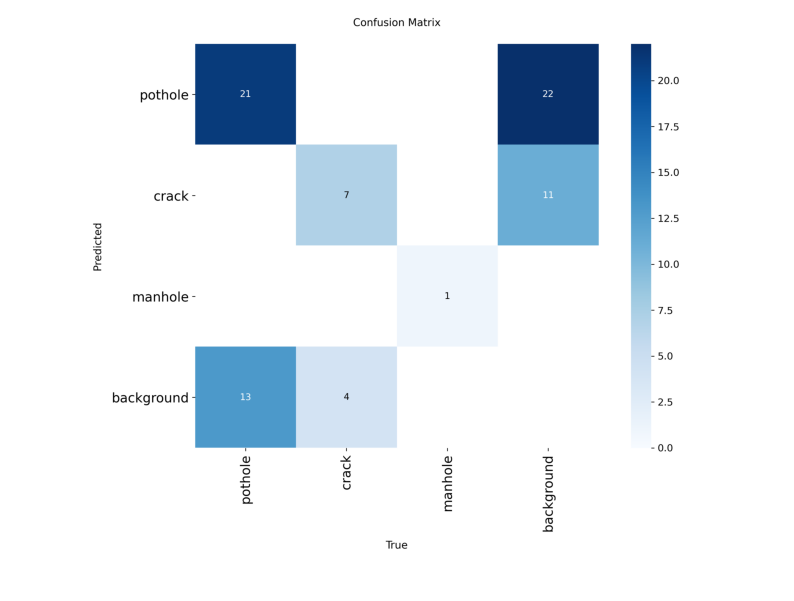

In [8]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import display, Markdown

# 1. Prepare Summary Table
metrics_data = []
for i, name in enumerate(CLASS_NAMES):
    # Extract metrics for each class from the validation results (m_val from previous cell)
    p, r, ap50, ap = m_val.box.class_result(i)
    f1 = 2 * p * r / (p + r + 1e-9)
    metrics_data.append({
        "Class": name,
        "Precision": f"{p:.4f}",
        "Recall": f"{r:.4f}",
        "F1-Score": f"{f1:.4f}",
        "mAP50": f"{ap50:.4f}"
    })

# Calculate mean metrics
df_metrics = pd.DataFrame(metrics_data)
display(Markdown("### ✅ Class-wise Performance Summary"))
display(df_metrics)

# 2. Display Confusion Matrix
# Note: YOLOv11 automatically saves confusion_matrix.png in the save_dir
cm_path = os.path.join(results.save_dir, 'confusion_matrix.png')

if os.path.exists(cm_path):
    display(Markdown("### 📊 Confusion Matrix"))
    plt.figure(figsize=(10, 8))
    img = plt.imread(cm_path)
    plt.imshow(img)
    plt.axis('off')
    plt.show()
else:
    print("Confusion Matrix image not found in the results directory.")

### 📈 ตรวจสอบกราฟการฝึกฝน (Training Curves)
เราจะดูว่า Loss ของ Validation พุ่งสูงขึ้นในช่วงท้ายหรือไม่เพื่อเช็ค Overfitting

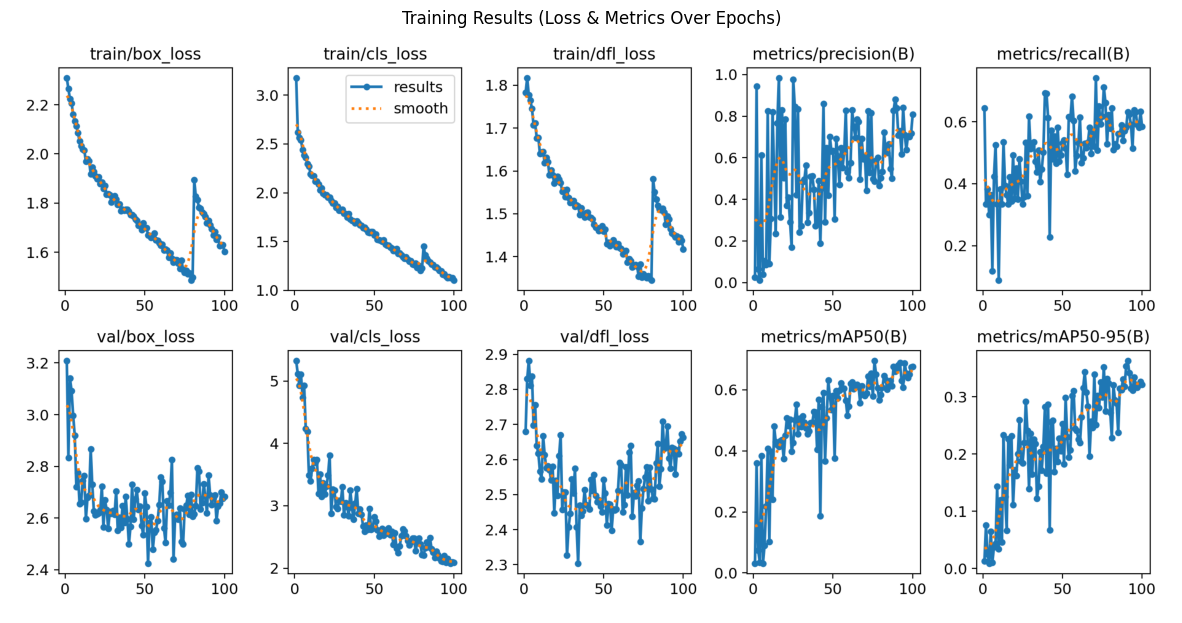

In [9]:
import matplotlib.pyplot as plt
import os

# กราฟหลักที่ YOLO บันทึกไว้
results_png = os.path.join(results.save_dir, 'results.png')

if os.path.exists(results_png):
    plt.figure(figsize=(15, 10))
    img = plt.imread(results_png)
    plt.imshow(img)
    plt.axis('off')
    plt.title("Training Results (Loss & Metrics Over Epochs)")
    plt.show()
else:
    print("Results graph not found.")

### 🔍 ทดสอบ Inference บน Test Set
สุ่มภาพจาก Test Set มาดูว่าโมเดล Predict ได้ตรงกับความจริงหรือไม่


0: 512x896 4 potholes, 13.4ms
1: 512x896 1 pothole, 13.4ms
2: 512x896 4 potholes, 13.4ms
3: 512x896 2 manholes, 13.4ms
4: 512x896 2 potholes, 4 cracks, 13.4ms
5: 512x896 8 potholes, 1 manhole, 13.4ms
6: 512x896 2 potholes, 1 crack, 13.4ms
7: 512x896 (no detections), 13.4ms
8: 512x896 1 pothole, 13.4ms
9: 512x896 1 pothole, 1 crack, 13.4ms
10: 512x896 3 potholes, 13.4ms
11: 512x896 5 cracks, 13.4ms
Speed: 3.9ms preprocess, 13.4ms inference, 0.8ms postprocess per image at shape (1, 3, 512, 896)


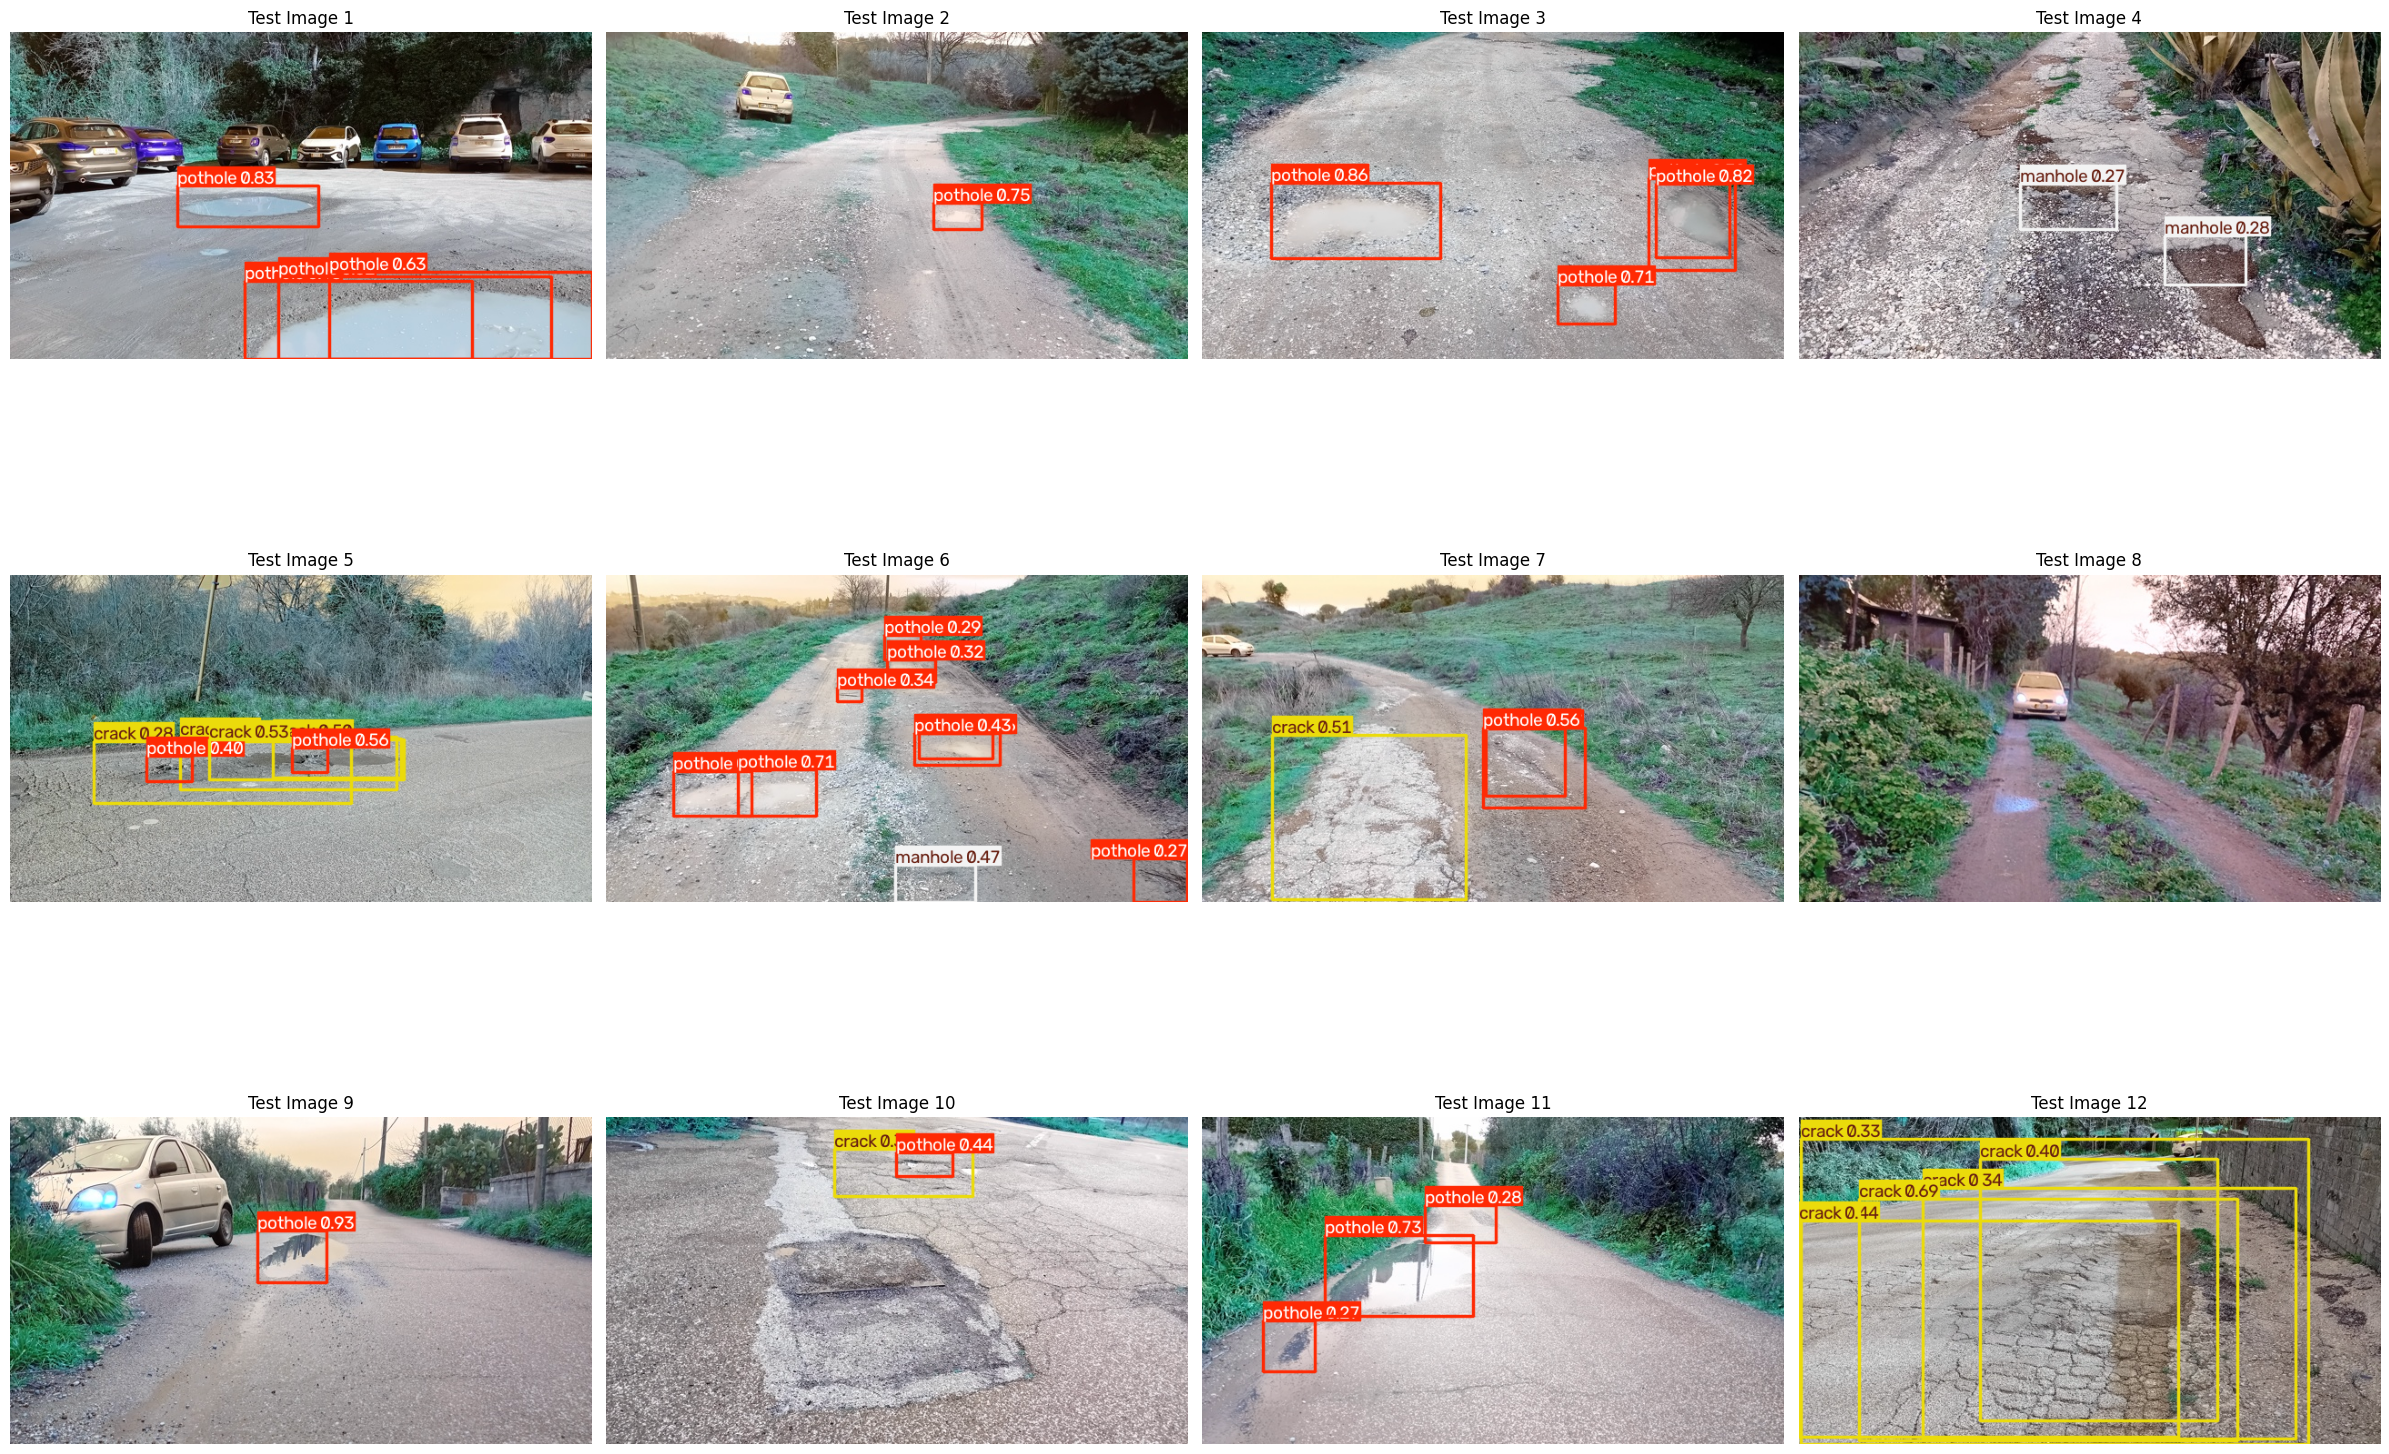

In [13]:
import glob
import random
import matplotlib.pyplot as plt
from PIL import Image

# สุ่มภาพจากชุด Test เพิ่มเป็น 8 ภาพ
num_samples = 12
test_images = glob.glob(f"{WORK_DIR}/images/test/*.*")
sampled_images = random.sample(test_images, min(num_samples, len(test_images)))

# รัน Inference
results_list = best.predict(source=sampled_images, conf=0.25, save=False)

# แสดงผลแบบตาราง (Grid)
cols = 4
rows = (len(results_list) + cols - 1) // cols
fig, axes = plt.subplots(rows, cols, figsize=(24, 6 * rows))
axes = axes.flatten()

for i, res in enumerate(results_list):
    im_array = res.plot()  # พล็อต Bounding Box ลงบนภาพ
    axes[i].imshow(im_array)
    axes[i].set_title(f"Test Image {i+1}", fontsize=12)
    axes[i].axis('off')

# ซ่อนแกนสำหรับช่องว่างที่เหลือในตาราง
for j in range(i + 1, len(axes)):
    axes[j].axis('off')

plt.tight_layout()
plt.show()

In [11]:
import os
from google.colab import files

# ชื่อไฟล์ zip ที่ต้องการ
zip_filename = "training_results.zip"

# บีบอัดโฟลเดอร์ runs (ปกติจะอยู่ที่ /content/runs)
if os.path.exists('/content/runs'):
    print(f"Zipping 'runs' folder into {zip_filename}...")
    os.system(f"zip -r {zip_filename} /content/runs")

    # ดาวน์โหลดลงเครื่อง
    print("Starting download...")
    files.download(zip_filename)
else:
    print("Error: 'runs' folder not found.")

Zipping 'runs' folder into training_results.zip...
Starting download...


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>